<a href="https://colab.research.google.com/github/arjangvt/CodeFolio/blob/main/ML/GAN/GAN_FlowersV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''
https://arminnorouzi.github.io/posts/2023/05/blog-post-12/

!pip install kaggle
from google.colab import files
files.upload()  # This will prompt you to upload the kaggle.json file
!kaggle datasets download -d jessicali9530/celeba-dataset
from google.colab import drive
drive.mount('/content/drive')
!unzip celeba-dataset.zip -d celeba
!ls celeba/img_align_celeba/img_align_celeba
!ls celeba/img_align_celeba/img_align_celeba
data_dir = "celeba/img_align_celeba/img_align_celeba"  # Update with the correct path
dataset = load_celeba_data(data_dir)
'''
# Download and prepare the Flowers-102 dataset
!pip install tensorflow kaggle
from google.colab import files

# Upload Kaggle API key
files.upload()  # Upload your kaggle.json file

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d alxmamaev/flowers-recognition

# Unzip the dataset
!unzip flowers-recognition.zip -d flowers


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
 99% 223M/225M [00:11<00:00, 23.8MB/s]
100% 225M/225M [00:11<00:00, 20.9MB/s]
Archive:  flowers-recognition.zip
  inflating: flowers/flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: flowers/flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: flowers/flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: flowers/flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: flowers/flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: flowers/flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: flowers/flowers/daisy/10300722094_28fa978807_n.jpg  
  inflating: flowers/flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: flowers/flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: flowers/flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: flowers/flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: flowers/flowers/daisy/10437929963

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [3]:
tf.config.run_functions_eagerly(True)

In [4]:
# Load and preprocess the dataset
data_dir = 'flowers/flowers'
batch_size = 32
img_height = 128
img_width = 128

dataset = image_dataset_from_directory(
    data_dir,
    shuffle=True,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

def normalize_img(image, label):
    image = (image / 127.5) - 1.0  # Normalize to [-1, 1]
    return image

dataset = dataset.map(normalize_img)

Found 4317 files belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


In [5]:
def plot_images(dataset, batch_index, image_index):
  for i, batch in enumerate(dataset):
    if i == batch_index:
        plt.imshow(batch[image_index].numpy())
        plt.show()

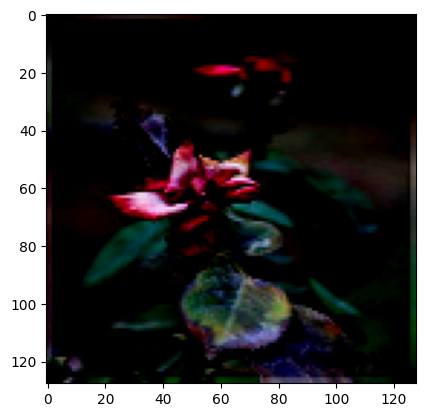

In [6]:
plot_images(dataset, 33,10)

In [7]:

# A deeper Generator Model
initializer = tf.keras.initializers.LecunNormal()

def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8 * 8 * 256, use_bias=False, kernel_initializer=initializer,  input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

'''
def make_generator_model():
    model = tf.keras.Sequential()

    model.add(layers.Dense(8*8*512, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 512)))
    assert model.output_shape == (None, 8, 8, 512)

    model.add(layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 128, 128, 3)

    return model
  '''

"\ndef make_generator_model():\n    model = tf.keras.Sequential()\n\n    model.add(layers.Dense(8*8*512, use_bias=False, input_shape=(100,)))\n    model.add(layers.BatchNormalization())\n    model.add(layers.LeakyReLU())\n\n    model.add(layers.Reshape((8, 8, 512)))\n    assert model.output_shape == (None, 8, 8, 512)\n\n    model.add(layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False))\n    model.add(layers.BatchNormalization())\n    model.add(layers.LeakyReLU())\n\n    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))\n    model.add(layers.BatchNormalization())\n    model.add(layers.LeakyReLU())\n\n    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))\n    model.add(layers.BatchNormalization())\n    model.add(layers.LeakyReLU())\n\n    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))\n    assert model.ou

In [8]:
#generator = make_generator_model()

#noise = tf.random.normal([1, 100])
#generated_image = generator(noise, training=False)

#plt.imshow(generated_image[0, :, :, 0])

In [9]:
# deeper discriminator

#initializer = tf.keras.initializers.HeNormal()
initializer = tf.keras.initializers.Orthogonal(gain=1.0)

def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same', input_shape=[128, 128, 3], kernel_initializer=initializer))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.5))

    model.add(layers.Conv2D(512, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.5))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


# optimized version
'''
Slower discriminator learning → Helps the generator catch up.
Less overfitting → Dropout prevents it from memorizing features too fast.
Better stability → Helps prevent mode collapse.
'''
'''
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same', input_shape=[128, 128, 3]))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.5))

    model.add(layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.6))  # More dropout in deep layers

    model.add(layers.Flatten())
    model.add(layers.Dense(1))  # Output logit (no activation, use BCE loss)

    return model
'''

'''
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[128, 128, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model
'''

"\ndef make_discriminator_model():\n    model = tf.keras.Sequential()\n    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[128, 128, 3]))\n    model.add(layers.LeakyReLU())\n    model.add(layers.Dropout(0.3))\n\n    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))\n    model.add(layers.LeakyReLU())\n    model.add(layers.Dropout(0.3))\n\n    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))\n    model.add(layers.LeakyReLU())\n    model.add(layers.Dropout(0.3))\n\n    model.add(layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same'))\n    model.add(layers.LeakyReLU())\n    model.add(layers.Dropout(0.3))\n\n    model.add(layers.Flatten())\n    model.add(layers.Dense(1))\n\n    return model\n"

In [10]:
def get_decision(decision):
  """
  This function takes in a decision tensor generated by the discriminator and
  prints whether the image is real or generated by the AI. If the decision value
  is less than 0, the image is considered to be generated by the AI, and
  if it is greater than or equal to 0, the image is considered to be real.

  Input:
  decision: Tensor of shape (1, 1) containing the decision value for an image generated by the discriminator

  Returns:
  None
  """

  val = decision.numpy()[0, 0]
  if val < 0:
    print("AI generated image")
  else:
    print("real image")


In [11]:
# Define loss functions and optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# some notes
'''
Use Label Smoothing if:

Your discriminator is overpowering the generator.
You need stabilized training to prevent mode collapse.
Use Noisy Labels (Your Approach) if:

You want to introduce regularization in the discriminator.
You need the discriminator to be less confident but still use binary labels.

'''

# Label Smoothing solutions
def discriminator_loss(real_output, fake_output):
    real_labels = tf.ones_like(real_output) * 0.9  # Label smoothing for real
    fake_labels = tf.zeros_like(fake_output) + 0.1  # Label smoothing for fake

    # Add small Gaussian noise to discriminator output
    real_output_noisy = real_output + 0.05 * tf.random.normal(tf.shape(real_output))
    fake_output_noisy = fake_output + 0.05 * tf.random.normal(tf.shape(fake_output))

    real_loss = cross_entropy(real_labels, real_output_noisy)  # Ensure same shape
    fake_loss = cross_entropy(fake_labels, fake_output_noisy)  # Ensure same shape

    return real_loss + fake_loss

# Noiosy label solutions
'''
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output + 0.05 * tf.random.normal(tf.shape(real_output)))
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output + 0.05 * tf.random.normal(tf.shape(fake_output)))
    total_loss = real_loss + fake_loss
    return total_loss
'''


'''
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss
'''

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator = make_generator_model()
discriminator = make_discriminator_model()
#print(type(discriminator))
#get_decision(discriminator)


#Separate Learning Rates: Use different learning rates for the generator and
#discriminator. Often, a lower learning rate for the discriminator (e.g., 0.0001)
#and a slightly higher one for the generator (e.g., 0.0002) can help
#balance their training.


generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [12]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i] * 127.5 + 127.5) / 255.0)
        #image = (predictions[i] * 127.5 + 127.5) / 255.0
        #image = (predictions[i] * 0.5) + 0.5
        #plt.imshow(image)
        plt.axis('off')
    print('image_at_epoch_{:04d}.png'.format(epoch))
    #plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

In [13]:
def add_noise_to_latent_vector(latent_vector, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(latent_vector), mean=0.0, stddev=noise_factor)
    noisy_latent_vector = latent_vector + noise
    return noisy_latent_vector


@tf.function
def train_step(images):
    noise = tf.random.normal([batch_size, 100])
    noisy_noise = add_noise_to_latent_vector(noise)  # Add noise to latent vector

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noisy_noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # **Compute Discriminator Accuracy**
    real_acc = tf.reduce_mean(tf.cast(real_output > 0.5, tf.float32))  # Real images classified as real
    fake_acc = tf.reduce_mean(tf.cast(fake_output < 0.5, tf.float32))  # Fake images classified as fake
    disc_acc = (real_acc + fake_acc) / 2  # Overall discriminator accuracy

    # **Compute Generator Accuracy**
    gen_acc = tf.reduce_mean(tf.cast(fake_output > 0.5, tf.float32))  # Fake images classified as real

    return disc_acc, gen_acc

In [18]:
disc_acc_history = []
gen_acc_history = []


def plot_accuracy():
    plt.figure(figsize=(8, 5))
    plt.plot(disc_acc_history, label="Discriminator Accuracy", color="red")
    plt.plot(gen_acc_history, label="Generator Accuracy", color="blue")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Generator vs Discriminator Accuracy Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

# train momre frequently
def train(dataset, epochs):
    counter = 0
    seed = tf.random.normal([16, 100])

    for epoch in range(epochs):
        counter += 1
        disc_acc_list = []
        gen_acc_list = []

        for image_batch in dataset:
            # Train the generator twice for every one discriminator update
            for _ in range(3):  # Generator updates twice for every 1 discriminator update
                disc_acc, gen_acc = train_step(image_batch)
                gen_acc_list.append(gen_acc.numpy())  # Store generator accuracy

            # Now train the discriminator once after two generator updates
            disc_acc, gen_acc = train_step(image_batch)
            disc_acc_list.append(disc_acc.numpy())  # Store discriminator accuracy

        # Compute average accuracy for the epoch
        avg_disc_acc = sum(disc_acc_list) / len(disc_acc_list)
        avg_gen_acc = sum(gen_acc_list) / len(gen_acc_list)

        disc_acc_history.append(avg_disc_acc)
        gen_acc_history.append(avg_gen_acc)

        print(f"Epoch {epoch+1}, Discriminator Accuracy: {avg_disc_acc:.4f}, Generator Accuracy: {avg_gen_acc:.4f}")

        # Save generated images every 10 epochs or at epoch 500
        if counter % 10 == 0 or counter == 500:
            generate_and_save_images(generator, epoch + 1, seed)
            plot_accuracy()

'''
def train(dataset, epochs):
    counter = 0
    seed = tf.random.normal([16, 100])

    for epoch in range(epochs):
        counter += 1
        disc_acc_list = []
        gen_acc_list = []

        for image_batch in dataset:
            disc_acc, gen_acc = train_step(image_batch)
            disc_acc_list.append(disc_acc.numpy())
            gen_acc_list.append(gen_acc.numpy())

        # Compute average accuracy for the epoch
        avg_disc_acc = sum(disc_acc_list) / len(disc_acc_list)
        avg_gen_acc = sum(gen_acc_list) / len(gen_acc_list)

        disc_acc_history.append(avg_disc_acc)
        gen_acc_history.append(avg_gen_acc)

        print(f"Epoch {epoch+1}, Discriminator Accuracy: {avg_disc_acc:.4f}, Generator Accuracy: {avg_gen_acc:.4f}")

        if counter % 10 == 0 or counter == 500:
            generate_and_save_images(generator, epoch + 1, seed)

        plot_accuracy()
  '''

'\ndef train(dataset, epochs):\n    counter = 0\n    seed = tf.random.normal([16, 100])\n\n    for epoch in range(epochs):\n        counter += 1\n        disc_acc_list = []\n        gen_acc_list = []\n\n        for image_batch in dataset:\n            disc_acc, gen_acc = train_step(image_batch)\n            disc_acc_list.append(disc_acc.numpy())\n            gen_acc_list.append(gen_acc.numpy())\n\n        # Compute average accuracy for the epoch\n        avg_disc_acc = sum(disc_acc_list) / len(disc_acc_list)\n        avg_gen_acc = sum(gen_acc_list) / len(gen_acc_list)\n\n        disc_acc_history.append(avg_disc_acc)\n        gen_acc_history.append(avg_gen_acc)\n\n        print(f"Epoch {epoch+1}, Discriminator Accuracy: {avg_disc_acc:.4f}, Generator Accuracy: {avg_gen_acc:.4f}")\n\n        if counter % 10 == 0 or counter == 500:\n            generate_and_save_images(generator, epoch + 1, seed)\n\n        plot_accuracy()\n  '

In [ ]:
train(dataset, epochs=20)

Epoch 1, Discriminator Accuracy: 0.9825, Generator Accuracy: 0.0041
Epoch 2, Discriminator Accuracy: 0.9686, Generator Accuracy: 0.0076
Epoch 3, Discriminator Accuracy: 0.9624, Generator Accuracy: 0.0127
Epoch 4, Discriminator Accuracy: 0.9681, Generator Accuracy: 0.0117


In [ ]:
noise = tf.random.normal([1, 100])
generated_image_2 = generator(noise, training=False)
plt.imshow((generated_image_2[0, :, :, 0] * 128), cmap=None)
#plt.imshow(generated_image_2[0, :, :, 0] * 127.5 + 127.5, cmap='gray')

In [ ]:
decision_2 = discriminator(generated_image_2)
get_decision(decision_2)

In [ ]:
count = 0
for image in dataset:
  # show images
  plt.imshow(image[0, :, :, 0] ,cmap=None)
  plt.show()

  # predict
  decision = discriminator(tf.expand_dims(image[0 , :, :, :], axis=0))
  get_decision(decision)

  count += 1
  if count > 5:
    break

In [ ]:
for i in range(0, 5):
  # show images
  noise = tf.random.normal([1, 100])
  generated_image = generator(noise, training=False)

  plt.imshow(generated_image[0, :, :, 0] * 127.5 + 127.5)
  plt.show()
  # predict
  decision = discriminator(generated_image)
  get_decision(decision)


In [ ]:
result = {'correct' : 0,
          'incorrect' : 0}

for image in dataset:
  # predict
  decision = discriminator(tf.expand_dims(image[0 , :, :, :], axis=0))
  get_decision(decision)
  if decision.numpy()[0, 0] > 0:
    result['correct'] += 1
  else:
    result['incorrect'] += 1

In [ ]:
percentage_correct_real = round(100*result['correct']/len(dataset))

print('Discriminator can detect {}% of real image correctly as real image!'.format(percentage_correct_real))

In [ ]:
result_generator = {'correct' : 0,
                    'incorrect' : 0}
for i in range(0, len(dataset)):
  # show images
  noise = tf.random.normal([1, 100])
  generated_image = generator(noise, training=False)

  # predict
  decision = discriminator(generated_image)
  get_decision(decision)
  if decision.numpy()[0, 0] < 0:
    result_generator['correct'] += 1
  else:
    result_generator['incorrect'] += 1

In [ ]:
percentage_correct_fake = round(100*result_generator['correct']/len(dataset))
percentage_generator_tricked = round(100*result_generator['incorrect']/len(dataset))

print('Discriminator can detect {}% of generated image correctly as fake image!'.format(percentage_correct_fake))
print('Generator can trick discirmator in {}% of generated iamges!'.format(percentage_generator_tricked))